## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd




In [3]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [4]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [5]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


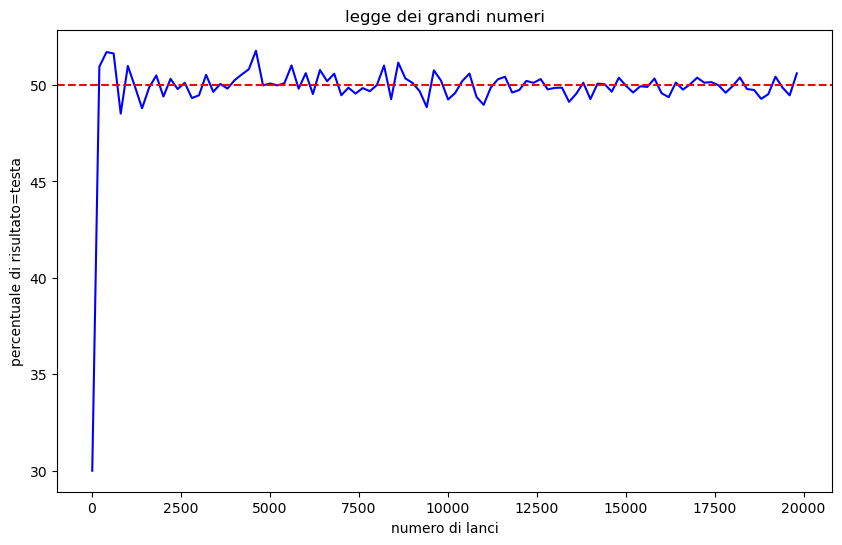

In [6]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Di

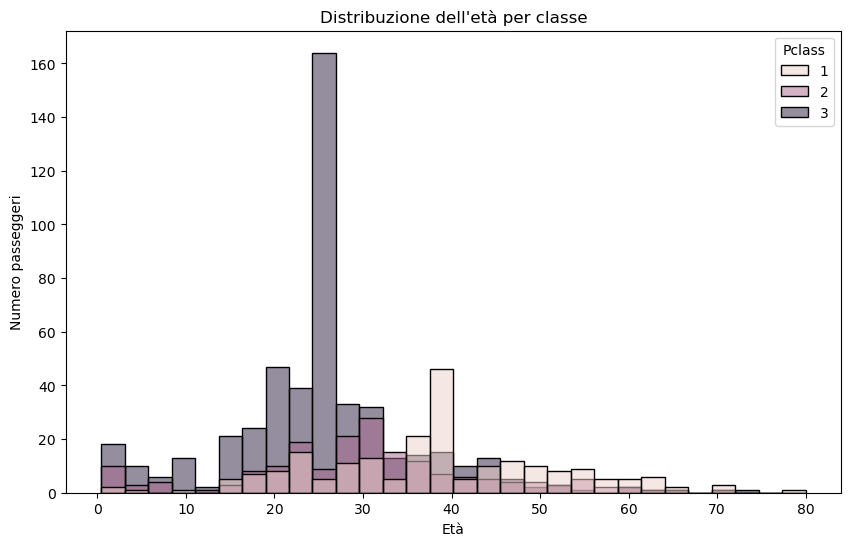

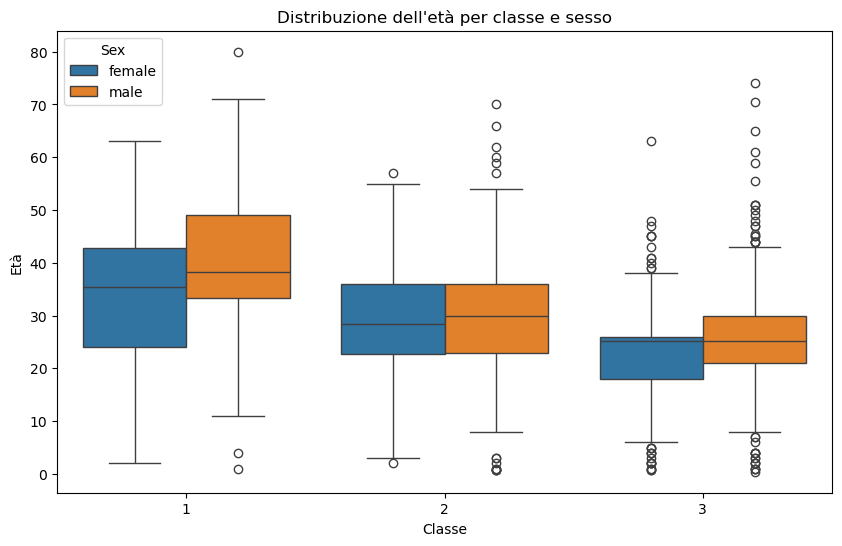

In [7]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carico il dataset Titanic da URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Mostro le prime righe del dataset
print(df.head())

# 1. Numero di righe e colonne
print("Dimensioni dataset:")
print(df.shape)#qua c'è la funzione che ti dice quante righe o colonne ha il dataset

# 2. Valori mancanti per colonna
print("\nValori mancanti per colonna:")
print(df.isnull().sum())#quesa funzione conta i valori mancanti colonna per colonna

# 3. Riempio i valori mancanti di Embarked con il valore più frequente
moda_embarked = df["Embarked"].mode()[0]#.mode [0]prende in input il valore piu frequente di embarked
df["Embarked"] = df["Embarked"].fillna(moda_embarked)

# Controllo che Embarked non abbia più valori mancanti
print("\nValori mancanti dopo riempimento Embarked:")
print(df["Embarked"].isnull().sum())

# 4. Controllo righe duplicate
duplicati = df.duplicated().sum()
print("\nNumero righe duplicate:")
print(duplicati)

# 5. Calcolo età media per classe PRIMA del riempimento
eta_media_per_classe = df.groupby("Pclass")["Age"].mean()#calcola l’età media separatamente per prima, seconda e terza classe.
print("\nEtà media per classe:")
print(eta_media_per_classe)

# Riempio i valori mancanti di Age con l'età media della rispettiva classe
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda colonna: colonna.fillna(colonna.mean())
)

# Controllo che Age non abbia più valori mancanti
print("\nValori mancanti Age dopo riempimento:")
print(df["Age"].isnull().sum())

# 6. Visualizzo la distribuzione dell'età per classe
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Age", hue="Pclass", bins=30)
plt.title("Distribuzione dell'età per classe")
plt.xlabel("Età")
plt.ylabel("Numero passeggeri")
plt.show()

# 7. Visualizzo la distribuzione dell'età per classe divisa per sesso
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex")
plt.title("Distribuzione dell'età per classe e sesso")
plt.xlabel("Classe")
plt.ylabel("Età")
plt.show()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print(df.head())

print(df["species"].value_counts())

media_petali = df.groupby("species")[["petal_length", "petal_width"]].mean()
print(media_petali)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Dimensioni dei petali per specie")
plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.show()

df["petal_area"] = df["petal_length"] * df["petal_width"]

analisi_area = df.groupby("species")["petal_area"].agg(["mean", "min", "max", "std"])
print(analisi_area)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="species", y="petal_area")
plt.title("Distribuzione dell'area del petalo per specie")
plt.xlabel("Specie")
plt.ylabel("Area petalo")
plt.show()